In [3]:
import pandas as pd

In [7]:
file = "Downloads/dark_store_inventory.xlsx"

df = pd.read_excel(file)

df.shape
df.columns

Index(['Store_ID', 'Store_City', 'Category', 'Stock_Received', 'Units_Sold',
       'Units_Expired_Wasted', 'Unit_Cost(Rs.)', 'Restock_Date',
       'TOTAL Financial_Loss'],
      dtype='str')

In [11]:
df['Stock_Received'] = pd.to_numeric(df['Stock_Received'], errors='coerce')
df['Units_Sold'] = pd.to_numeric(df['Units_Sold'], errors='coerce')
df['Units_Expired_Wasted'] = pd.to_numeric(df['Units_Expired_Wasted'], errors='coerce')
df['Unit_Cost(Rs.)'] = pd.to_numeric(df['Unit_Cost(Rs.)'], errors='coerce')
df['TOTAL Financial_Loss'] = pd.to_numeric(df['TOTAL Financial_Loss'], errors='coerce')

wastage_rate = (
    df['Units_Expired_Wasted'].sum() /
    df['Stock_Received'].sum()
) * 100

print("Total Stock Received:", df['Stock_Received'].sum())
print("Total Units Sold:", df['Units_Sold'].sum())
print("Total Wasted Units:", df['Units_Expired_Wasted'].sum())
print("Wastage Rate:", round(wastage_rate, 2), "%")
print("Total Financial_Loss:", df['TOTAL Financial_Loss'].sum())
print("Average Unit Cost:", round(df['Unit_Cost(Rs.)'].mean(), 2))

Total Stock Received: 25471507
Total Units Sold: 20733044
Total Wasted Units: 4738463
Wastage Rate: 18.6 %
Total Financial_Loss: 166279210
Average Unit Cost: 35.1


In [13]:
loss_by_city = df.groupby('Store_City')['TOTAL Financial_Loss'].sum().sort_values(ascending=False)
print("Financial Loss by Store City")
print(loss_by_city)


loss_by_category = df.groupby('Category')['TOTAL Financial_Loss'].sum().sort_values(ascending=False)
print("\nFinancial Loss by Category")
print(loss_by_category)


city_wastage = df.groupby('Store_City').agg(
    Stock_Received=('Stock_Received', 'sum'),
    Wasted_Units=('Units_Expired_Wasted', 'sum')
)

city_wastage['Wastage_Rate_%'] = (
    city_wastage['Wasted_Units'] /
    city_wastage['Stock_Received'] * 100
)

print("\nWastage Rate by Store City")
print(city_wastage.sort_values('Wastage_Rate_%', ascending=False))


category_analysis = df.groupby('Category').agg(
    Stock_Received=('Stock_Received', 'sum'),
    Units_Sold=('Units_Sold', 'sum'),
    Wasted_Units=('Units_Expired_Wasted', 'sum')
)

print("\nStock Received vs Sold vs Wasted by Category")
print(category_analysis)


top_stores = (
    df.groupby('Store_ID')['TOTAL Financial_Loss']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Stores by Financial Loss")
print(top_stores)


wasted_category = (
    df.groupby('Category')['Units_Expired_Wasted']
    .sum()
    .sort_values(ascending=False)
)

print("\nExpired & Wasted Units by Category")
print(wasted_category)

Financial Loss by Store City
Store_City
Kolkata      17334080
Surat        17001555
Pune         16839605
Jaipur       16798980
Ahmedabad    16737050
Chennai      16735905
Hyderabad    16586330
Mumbai       16263640
Bangalore    16224715
Delhi        15757350
Name: TOTAL Financial_Loss, dtype: int64

Financial Loss by Category
Category
Fruits        39655400
Bakery        35907345
Beverages     31707240
Dairy         24121710
Snacks        19369975
Vegetables    15517540
Name: TOTAL Financial_Loss, dtype: int64

Wastage Rate by Store City
            Stock_Received  Wasted_Units  Wastage_Rate_%
Store_City                                              
Pune               2544531        480708       18.891811
Ahmedabad          2558502        479813       18.753669
Kolkata            2620189        491165       18.745403
Delhi              2420888        450817       18.621968
Jaipur             2565713        476601       18.575772
Bangalore          2501168        464415       18.567925

In [14]:
import matplotlib.pyplot as plt

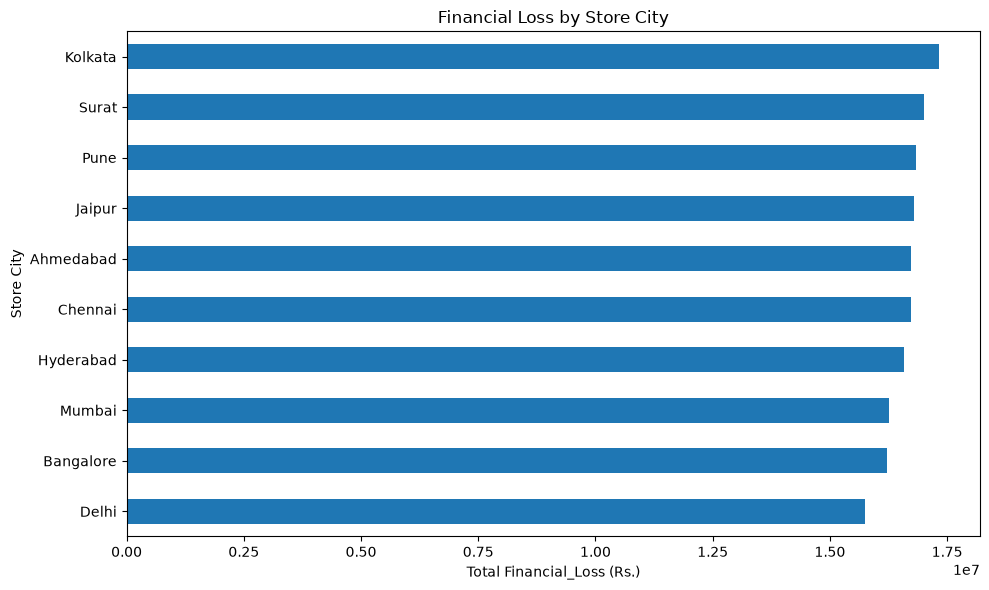

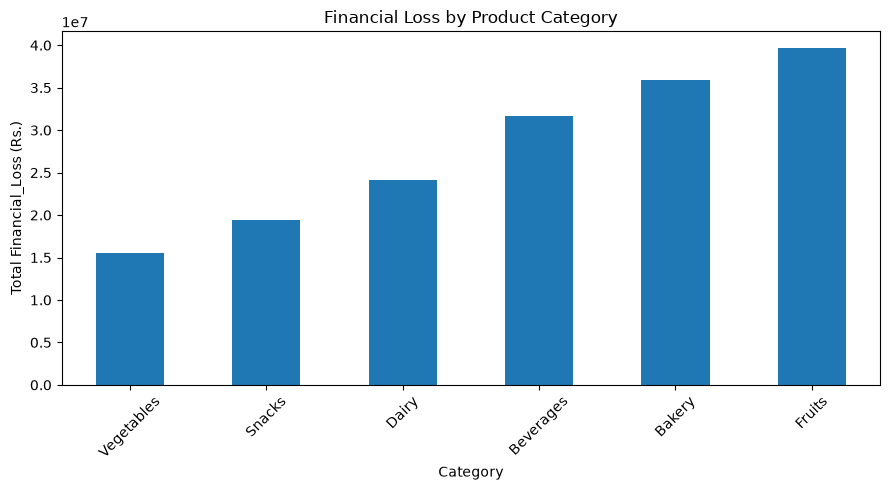

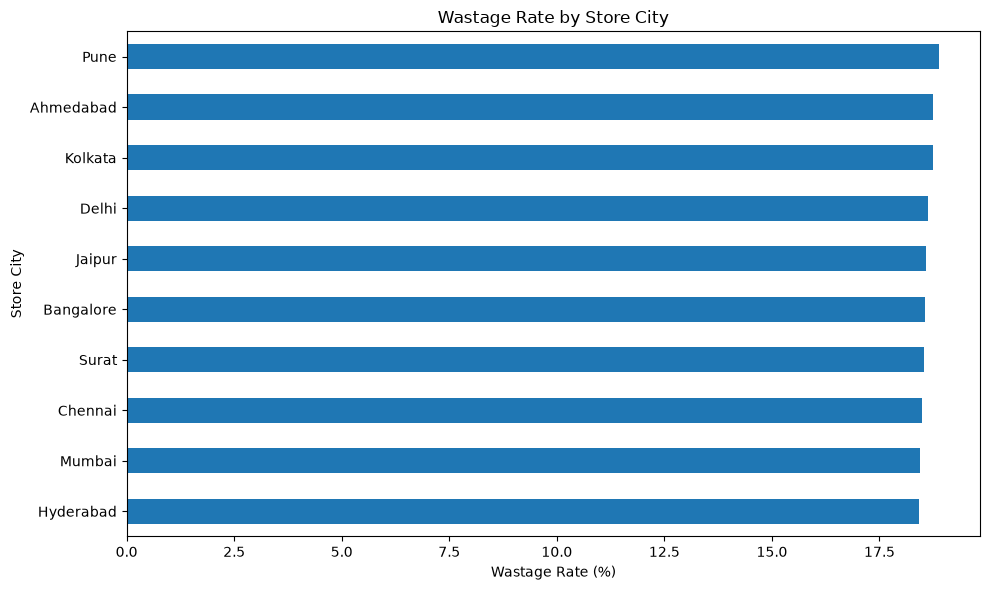

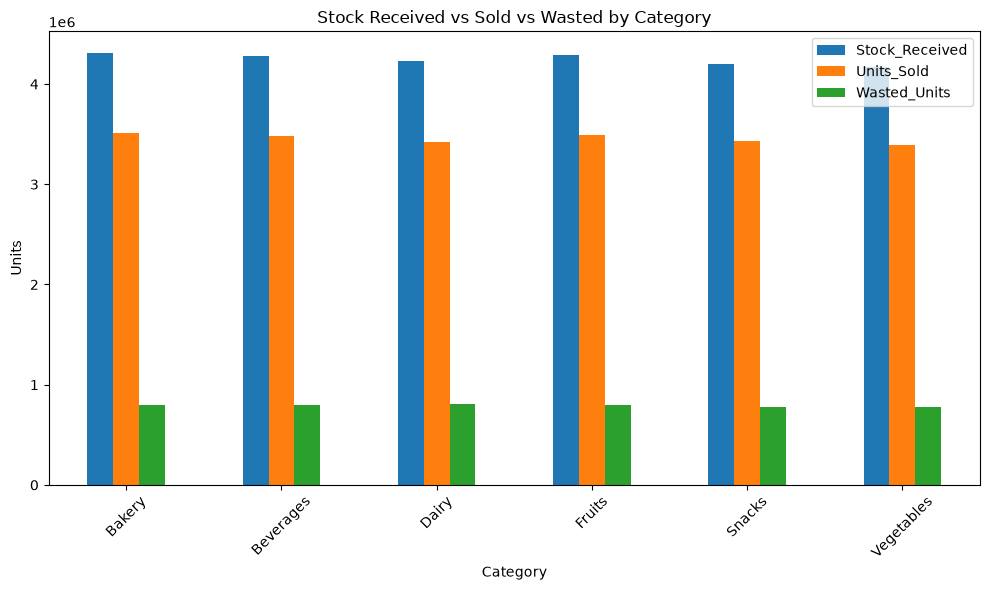

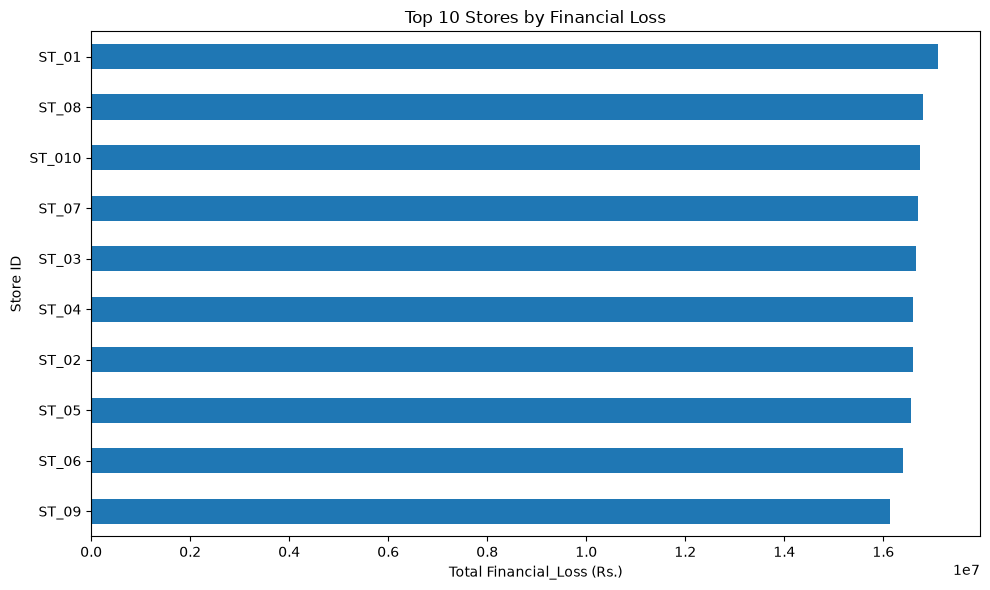

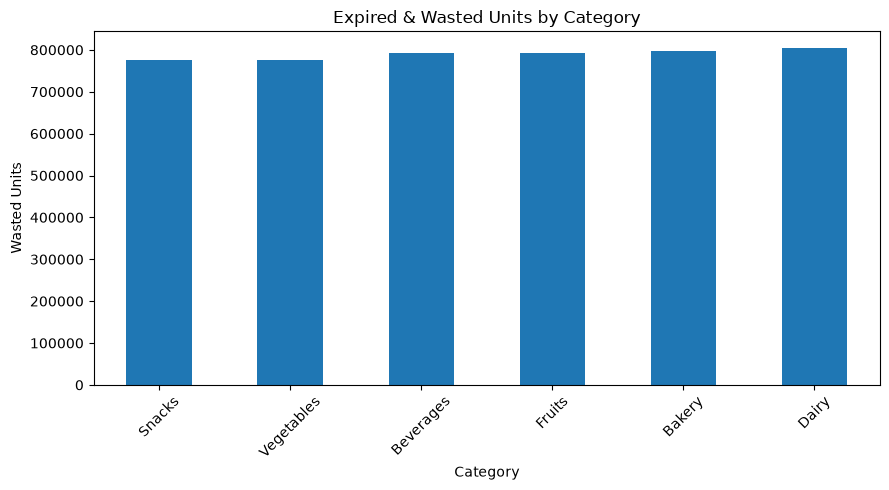

In [15]:
loss_by_city.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Financial Loss by Store City")
plt.xlabel("Total Financial_Loss (Rs.)")
plt.ylabel("Store City")
plt.tight_layout()
plt.show()


loss_by_category.sort_values().plot(kind='bar', figsize=(9,5))
plt.title("Financial Loss by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Financial_Loss (Rs.)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


city_wastage['Wastage_Rate_%'].sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Wastage Rate by Store City")
plt.xlabel("Wastage Rate (%)")
plt.ylabel("Store City")
plt.tight_layout()
plt.show()


category_analysis.plot(kind='bar', figsize=(10,6))
plt.title("Stock Received vs Sold vs Wasted by Category")
plt.xlabel("Category")
plt.ylabel("Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


top_stores.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Stores by Financial Loss")
plt.xlabel("Total Financial_Loss (Rs.)")
plt.ylabel("Store ID")
plt.tight_layout()
plt.show()


wasted_category.sort_values().plot(kind='bar', figsize=(9,5))
plt.title("Expired & Wasted Units by Category")
plt.xlabel("Category")
plt.ylabel("Wasted Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()